In [193]:
# Objectives:

# 1.Provide the learner some more practice for exploratory data analysis.
# 2.Equip the learner to fit and evaluate a linear regression model.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("/content/cereal.csv")
data.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


Text(0.5, 1.0, 'Vitamins')

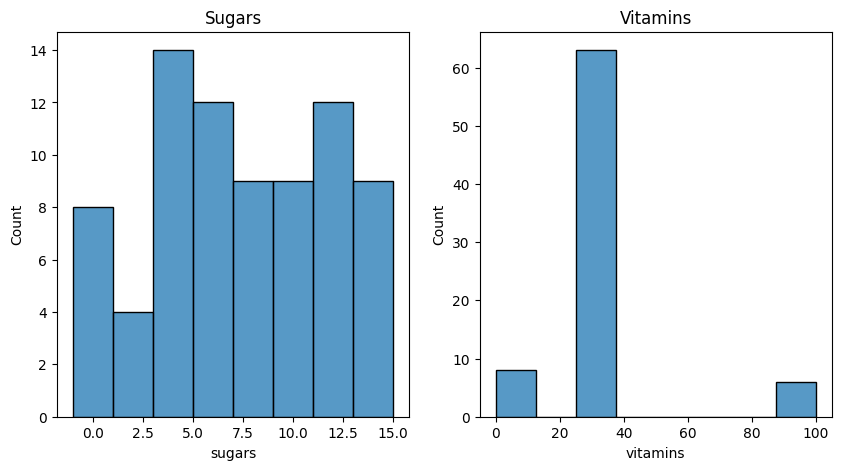

In [211]:
# Questions:
# 1.Load the data from “cereal.csv” and plot histograms of sugar and vitamin content across different cereals.
# [Hint: Extract values of a specific column using their labels and use hist method of pyplot ]

fig, axes=plt.subplots(1,2, figsize=(10,5))
sns.histplot(data=data,x='sugars', ax=axes[0])
axes[0].set_title("Sugars")
sns.histplot(data=data,x='vitamins', ax=axes[1])
axes[1].set_title("Vitamins")

<Axes: xlabel='count', ylabel='labelled'>

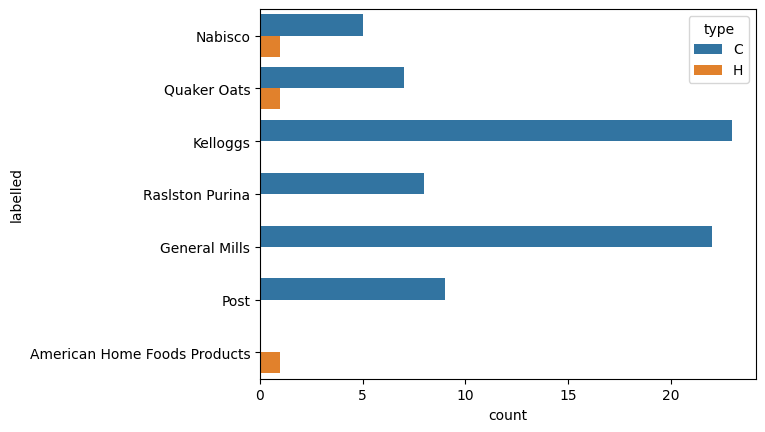

In [223]:
# 2.	The names of the manufactures are coded using alphabets, create a new column with their full name using the below mapping.


# 'N': 'Nabisco',
# 'Q': 'Quaker Oats',
# 'K': 'Kelloggs',
# 'R': 'Raslston Purina',
# 'G': 'General Mills' ,
# 'P' :'Post' ,
# 'A':'American Home Foods Products'

# Create a bar plot where each manufacturer is on the y axis and the height of the bars depict the number of cereals manufactured by them.
# [Hint: Try using countplot this time or bar method of pyplot]

labels={'N': 'Nabisco',
'Q': 'Quaker Oats',
'K': 'Kelloggs',
'R': 'Raslston Purina',
'G': 'General Mills' ,
'P' :'Post' ,
'A':'American Home Foods Products'}

data['labelled']=data['mfr'].map(labels)
sns.countplot(data=data,y='labelled', hue='type')

In [ ]:
data=data.drop(columns='labelled')

In [248]:
# 3.	Extract the rating as your target variable ‘y’ and all numerical parameters as your predictors ‘x’. Separate 25% of your data as test set.

x=data.iloc[:,3:-1]
y=data.iloc[:,-1]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.25)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(57, 12) (20, 12) (57,) (20,)


In [260]:
# 4.	Fit a linear regression module and measure the mean squared error on test dataset.
# [ Hint: Explore linear models and metrics section of sklearn documentation]

from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_difference=y_pred-y_test

from sklearn.metrics import mean_squared_error, r2_score
mse=mean_squared_error(y_test,y_pred)
print("Mean squared error : ", mse)
print("Accuracy : ", r2_score(y_pred,y_test))

Mean squared error :  2.006937517637068e-13
Accuracy :  0.999999999999999
